# Part 1 walkthrough — Explain the boundary & dividend ordering

Step-by-step companion to `part1_writeup.md`. Every cell calls a function from the modules:

| module | role |
|---|---|
| `config.py` | fixed parameters, time grid with **integer** dividend indices, cap $U_j$ |
| `lognormal_kernel.py` | exact one-step Gaussian expectation on a log grid |
| `grid_solver.py` | **our own** grid-exercise solver (put/call, dividend/exercise ordering) |
| `analytics.py` | Black–Scholes closed form, used only for validation |
| `experiments_part1.py` | experiments E1–E4 |
| `plotting.py` | figures (axis $u=T-t$, $b/K$) |

> The supplied `reference_solver.py` was not available, so "ref" below means **our** solver. Re-run the E3 diagnostics with the supplied solver later.

In [1]:
import pandas as pd, numpy as np
pd.set_option("display.width", 160); pd.set_option("display.precision", 6)
import config as cfg, experiments_part1 as E, plotting as P
from IPython.display import Image
for N in cfg.NS:
    tg = cfg.TimeGrid(N)
    print(f"N={N}: h={tg.h:.6f}, dividend indices={tg.div_idx}, j*={tg.j_star}")

N=180: h=0.004167, dividend indices=(50, 110, 170), j*=170
N=360: h=0.002083, dividend indices=(100, 220, 340), j*=340


## Step 0 — Can we trust our solver?

**Experiment design.** Turn off early exercise and compare with the closed form. With proportional dividends, a European option equals Black–Scholes at spot $S_0(1-\delta)^3$. This one check tests three things at once: the kernel, the exact dividend shift, and the truncated domain. Then we halve $dx$ to check spatial convergence.

**What to look for.**
* The European error does **not** grow with $N$. This is the purpose of the variance correction, $\sigma^2h - dx^2/6$.
* Refinement changes values by about $10^{-5}$.

In [2]:
import validate_solver as VS
VS.check_kernel(); VS.check_european(); VS.check_refinement()

N=180: L=155, sum w - 1 = 2.66e-14, E[e^Y]/e^(rh) - 1 = 2.24e-14
N=360: L=110, sum w - 1 = 1.73e-14, E[e^Y]/e^(rh) - 1 = 1.31e-14

European check: grid - closed form (dollars)
  N=180 delta=0.0     put : -5.43e-06  -5.00e-06  -1.95e-05
  N=180 delta=0.0     call: -1.12e-06  +1.01e-05  -1.95e-05


  N=180 delta=0.0125  put : -5.00e-06  -6.02e-06  -1.93e-05
  N=180 delta=0.0125  call: -8.46e-07  +8.57e-06  -1.93e-05


  N=360 delta=0.0     put : -5.43e-06  -5.00e-06  -1.95e-05
  N=360 delta=0.0     call: -1.12e-06  +1.01e-05  -1.95e-05


  N=360 delta=0.0125  put : -5.00e-06  -6.02e-06  -1.93e-05
  N=360 delta=0.0125  call: -8.46e-07  +8.57e-06  -1.93e-05

Spatial refinement, American (grid-exercise) put, N=180
  delta=0.0     m= 5 dx=2.52e-03 V(60,80,100) = 39.999991, 20.868824, 8.807793   [0.02s]


  delta=0.0     m=10 dx=1.26e-03 V(60,80,100) = 39.999996, 20.868808, 8.807838   [0.06s]


  delta=0.0     m=20 dx=6.29e-04 V(60,80,100) = 39.999998, 20.868801, 8.807848   [0.22s]
  m=10 vs m=20: max|dV| = 1.05e-05 $, max|db| = 1.08e-03 $
  delta=0.0125  m= 5 dx=2.52e-03 V(60,80,100) = 39.999991, 22.109538, 10.126339   [0.03s]
  delta=0.0125  m=10 dx=1.26e-03 V(60,80,100) = 39.999996, 22.109547, 10.126390   [0.07s]


  delta=0.0125  m=20 dx=6.29e-04 V(60,80,100) = 39.999998, 22.109547, 10.126401   [0.22s]
  m=10 vs m=20: max|dV| = 1.20e-05 $, max|db| = 1.08e-03 $


## Step 1 — Direction of time

The horizontal axis is time remaining, $u=T-t$. **Calendar time advances right → left.** In panel (b), each dividend marker has the near-zero boundary on its **right** (just *before* the dividend in calendar time). The high post-jump boundary is on its **left**.

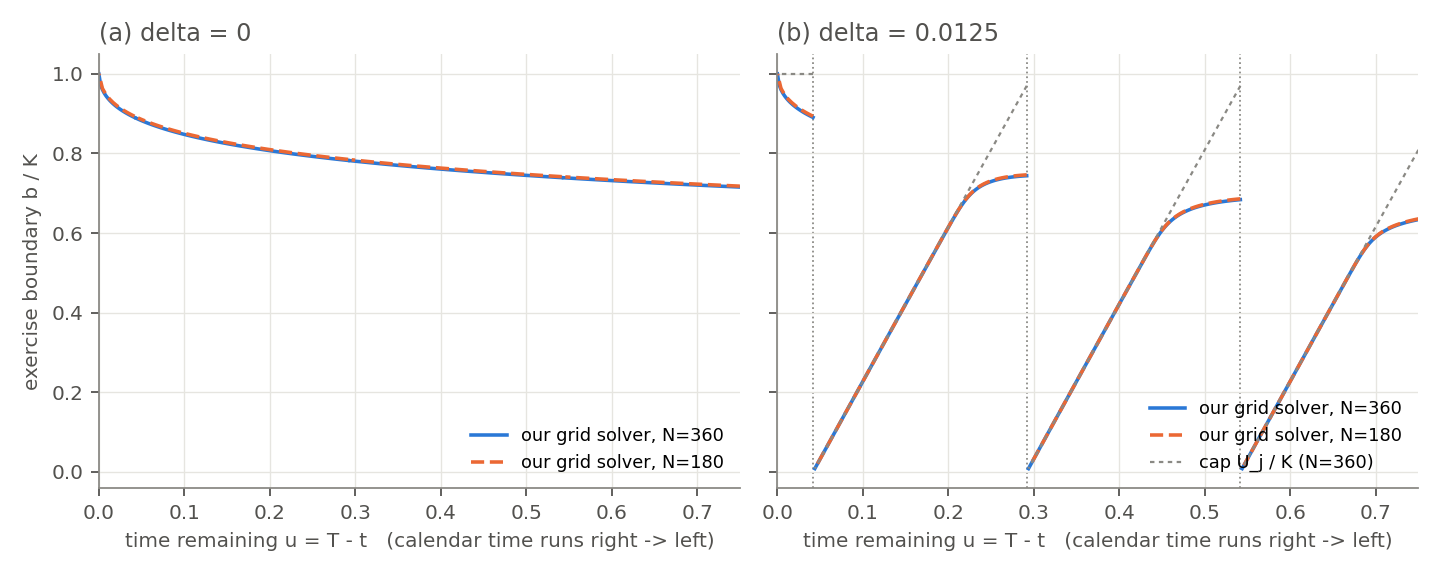

In [3]:
P.fig_boundaries("figures/p1_boundaries.png"); Image("figures/p1_boundaries.png")

## Step 2 — Item 1: never exercise the put just before the jump

**Design.** At each $d_k$, take the pre-jump value $W(s)=V(d_k^+,(1-\delta)s)$ from the solver and compare it with the pre-jump payoff $K-s$. The theory predicts $W(s)-(K-s)\ge\delta s>0$.

We then re-solve the put under three orderings:
* `after`: the assignment's rule (jump, then decide).
* `both`: exercise allowed on either side of the jump.
* `before`: exercise allowed only before the jump.

In [4]:
display(E.e1_dividend_identity()); display(E.e1_put_orderings())

,dividend,j,min_gap_pre,min_excess,ex_region_pre
0,d1,50,0.001154,-3.819167e-14,0
1,d2,110,0.001154,-4.307665e-14,0
2,d3,170,0.001154,-4.662937e-14,0


,ordering,"V(0,60)","V(0,80)","V(0,100)",max_abs_diff_vs_after
0,after,39.999996,22.109547,10.126390,0.000000
1,both,39.999996,22.109547,10.126390,0.000000
2,before,39.999996,22.098421,10.120087,0.013822


**Reading.**
* `min_excess` is about $-4\times10^{-14}$, i.e. zero. The gap is **exactly** $\delta s$ wherever the put is exercised at $d_k^+$.
* `both` equals `after` to machine precision: pre-jump exercise is worthless.
* `before` is strictly worse.

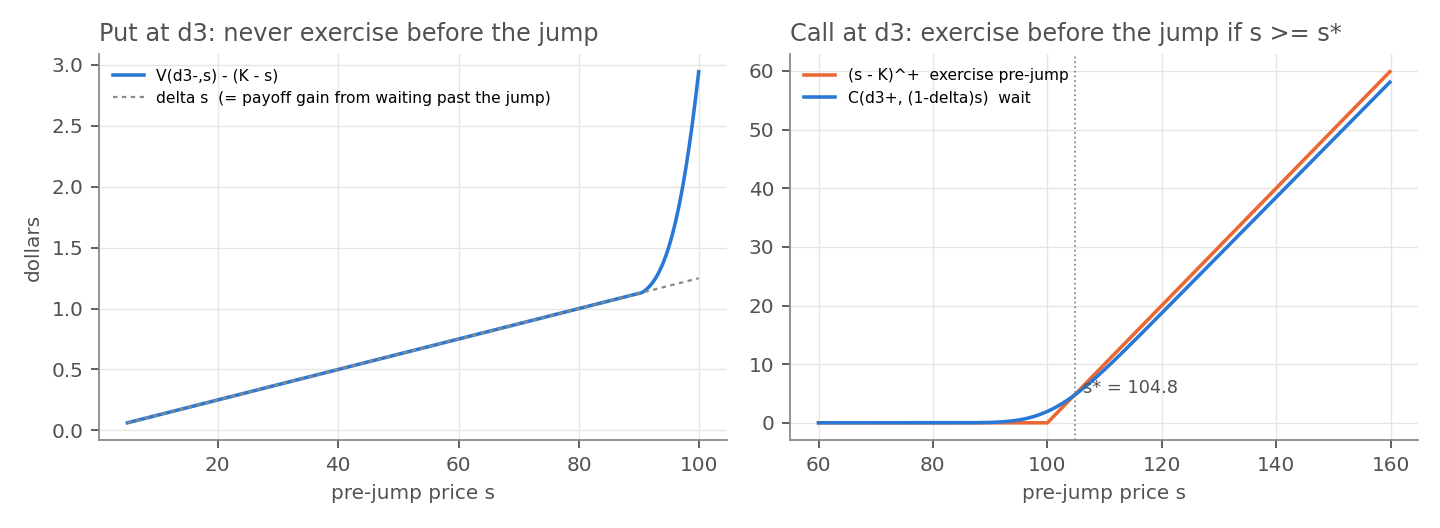

In [5]:
P.fig_pre_jump("figures/p1_pre_jump.png"); Image("figures/p1_pre_jump.png")

## Step 3 — Item 2: the cap and its limit

**Design.**
1. Check the lower bound $V\ge Ke^{-r\varepsilon}-(1-\delta)s$ on every grid node before each dividend.
2. Tabulate $b_j$ against $K(1-e^{-r\varepsilon})/\delta$ for the last few grid dates before each $d_k$.
3. Compute $\varepsilon^*(s)$, the $s$-dependent proximity.
4. Show that the one-step cap shrinks with $h$.
5. Show the limit at maturity.

In [6]:
print("worst slack of the lower bound:", {N: E.e2_lower_bound_check(N) for N in cfg.NS})
display(E.e2_cap_table(180))

worst slack of the lower bound: {180: np.float64(8.881784197001252e-13), 360: np.float64(6.430411758628907e-13)}


,dividend,j,steps_to_div,eps_years,b,cap,b_over_cap,b_over_K
0,d1,44,6,0.025000,9.752084,9.752084,1.0,0.097521
1,d1,45,5,0.020833,8.127563,8.127563,1.0,0.081276
2,d1,46,4,0.016667,6.502711,6.502711,1.0,0.065027
3,d1,47,3,0.012500,4.877529,4.877529,1.0,0.048775
4,d1,48,2,0.008333,3.252016,3.252016,1.0,0.032520
5,d1,49,1,0.004167,1.626174,1.626174,1.0,0.016262
6,d1,50,0,0.000000,68.603514,NaN,NaN,0.686035
7,d1,51,-1,-0.004167,68.518099,NaN,NaN,0.685181
8,d2,104,6,0.025000,9.752084,9.752084,1.0,0.097521
9,d2,105,5,0.020833,8.127563,8.127563,1.0,0.081276


In [7]:
display(E.e2_one_step_cap()); display(E.e2_proximity()); display(E.e2_maturity_limit())

,N,h,cap_one_step,b_one_step
0,180,0.004167,1.626174,"[1.6262, 1.6262, 1.6262]"
1,360,0.002083,0.813128,"[0.8131, 0.8131, 0.8131]"


,s,eps_star_years,eps_star_days,steps_N180,steps_N360
0,10,0.025636,9.357119,6.152626,12.305253
1,20,0.051304,18.725957,12.312958,24.625916
2,40,0.102737,37.498906,24.656815,49.313629
3,60,0.154299,56.319082,37.031725,74.063450
4,80,0.205991,75.186724,49.437846,98.875691
5,95,0.244846,89.368749,58.763013,117.526026


,N,delta,b_N-10/K,b_N-3/K,b_N-2/K,b_N-1/K
0,180,0.0000,0.893483,0.936883,0.947957,0.963436
1,180,0.0125,0.893483,0.936883,0.947957,0.963436
2,360,0.0000,0.917493,0.951829,0.960424,0.972285
3,360,0.0125,0.917493,0.951829,0.960424,0.972285


**An unexpected finding worth reporting.** Near each dividend the boundary sits **on** the cap, not merely below it. The reason is that for small $s$, exercise at $d_k^+$ is essentially certain, so the continuation value *equals* the wait-and-exercise value. This explains the straight lines in the Cox–Rubinstein figure, with slope $\approx rK/\delta$.

slope r/delta = 3.903213133554563


,dividend,steps_on_cap,eps_years,b_over_K_at_departure,max_b_over_K_before_div,N
0,d1,31,0.129167,0.502256,0.635644,180
1,d2,33,0.137500,0.534523,0.686035,180
2,d3,37,0.154167,0.598951,0.746259,180


,dividend,steps_on_cap,eps_years,b_over_K_at_departure,max_b_over_K_before_div,N
0,d1,60,0.125000,0.485931,0.633839,360
1,d2,61,0.127083,0.494010,0.683986,360
2,d3,61,0.127083,0.494013,0.744036,360


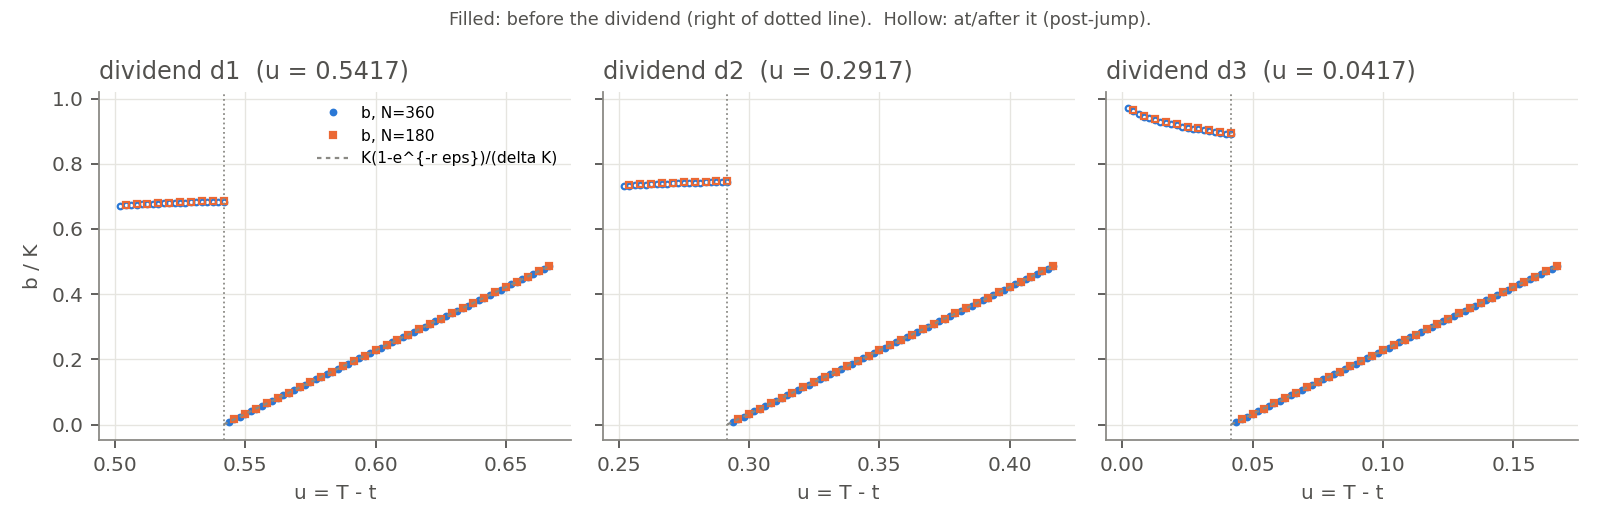

In [8]:
print("slope r/delta =", cfg.R/E.DELTA)
for N in cfg.NS: display(E.e2_cap_tightness(N).assign(N=N))
P.fig_cap_zoom("figures/p1_cap_zoom.png"); Image("figures/p1_cap_zoom.png")

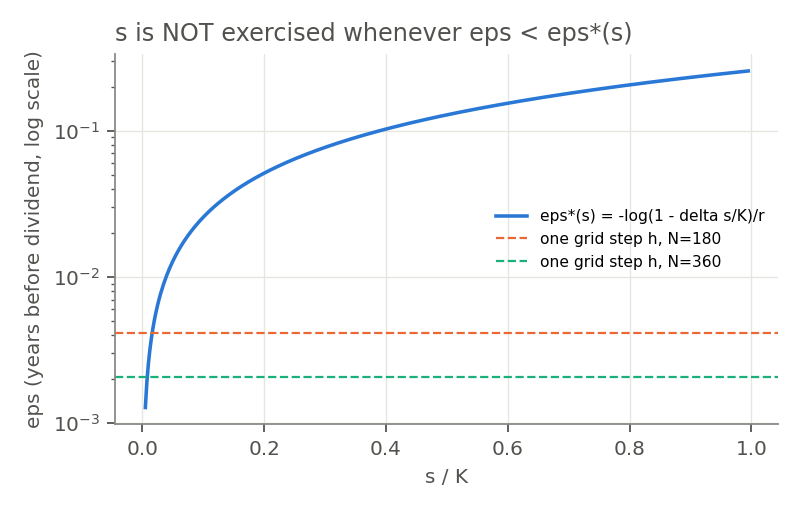

In [9]:
P.fig_proximity("figures/p1_proximity.png"); Image("figures/p1_proximity.png")

## Step 4 — Item 3: dividend ordering

**Design.**
* Compute the assignment's diagnostics $A$, $B$, $F$ with $M=$ ref (ours). Also compute $\max(V_0-V_\delta)^+$ at $t_0$ and on every date.
* Run a coupled Monte Carlo that mirrors the proof. The **same** normals drive both models. We compare:
  * one **common** stopping time, versus
  * a model-specific rule.

(Seed 9001 is ours and avoids the assignment's seed ranges.)

In [10]:
display(E.e3_ordering_diagnostics()); display(E.e3_coupled_mc())

,N,j_star,A,B,F,max_pos_V0_minus_Vd_t0,max_pos_V0_minus_Vd_all_j,max_abs_V_diff_j_ge_jstar
0,180,170,0,0.0,0.0,0.0,1.828724e-99,0.0
1,360,340,0,0.0,0.0,0.0,0.000000e+00,0.0


,rule,mean_Q0,mean_Qd,mean_diff,se_diff,frac_paths_Qd_lt_Q0
0,common tau (proof),8.751285,9.832313,1.081028,0.008493,0.0000
1,own tau per model,8.655491,9.656374,1.000883,0.019562,0.1241


**Reading.**
* With a common $\tau$, **no path** violates $Q_\delta\ge Q_0$.
* With model-specific $\tau$, about 12% of paths do, although the averages remain ordered.
* This is exactly why the proof fixes $\tau$ first and takes the supremum last.

The LS/NN rows of these diagnostics come later (Parts 3–4).

## Step 5 — Item 4: exercise timing for a call

**Design.** Solve the call four ways:
* European
* put-style ordering (jump, then decide)
* pre-jump-only exercise
* correct (both sides)

Then find the pre-jump thresholds $s^*_k$.

In [11]:
display(E.e4_call_orderings())
thr, other = E.e4_call_pre_div_threshold(); display(thr)
print("early-exercise nodes at any post-jump / non-dividend date (S<5K):", other)

,ordering,"C(0,80)","C(0,100)","C(0,120)","C(0,140)"
0,european,2.391821,9.903653,23.066092,39.775974
1,after (put-style),2.518306,10.402908,24.203078,41.802006
2,before,2.525086,10.419771,24.227796,41.828703
3,both (correct),2.525086,10.419771,24.227796,41.828703


,dividend,j,s_star_pre_jump,s_star_over_K
0,d1,50,139.737518,1.397375
1,d2,110,128.766889,1.287669
2,d3,170,104.764155,1.047642


early-exercise nodes at any post-jump / non-dividend date (S<5K): 0


**Reading.**
* The correct call must test exercise **before** applying the dividend.
* The put-style implementation instead exercises one grid step early and loses the interest $K(1-e^{-rh})$. Its value lies between the European and the correct values.
* For the put, `both` = `after` (Step 2), so jump-then-decide is exact.